# Customer segments: who are Brightbasket's customers, who is slipping away, and who responds to coupons?

Three questions:
1. **RFM segments.** Which groups of households drive the sales? (Scores and segments come from `sql/07_rfm.sql`.)
2. **Churn risk.** Who looks like they're leaving, and does my flag actually predict it?
3. **Coupon response.** Which customers redeem coupons: by RFM segment, and by age, income and household type (801 households with demographics).

In [ ]:
import os
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint
from sqlalchemy import create_engine, URL

password = os.environ.get("PG_PASSWORD") or getpass("PostgreSQL password: ")
engine = create_engine(URL.create("postgresql+psycopg2", username="postgres", password=password,
                                  host="localhost", port=5432, database="retail_promo"))

rfm = pd.read_sql("SELECT * FROM analysis.household_rfm", engine)
households = pd.read_sql("""
    SELECT household_key, campaigns_received, coupons_redeemed, has_demographics,
           age_desc, income_desc, hh_comp_desc, kid_category_desc, homeowner_desc
    FROM clean.households""", engine)
baskets = pd.read_sql("SELECT household_key, day, basket_value FROM clean.baskets", engine)
print(f"{len(rfm):,} households scored")

2,500 households scored


In [ ]:
BLUE, ORANGE, GREY, INK, MUTED, SURFACE = "#2a78d6", "#eb6834", "#a3a29c", "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#d6d5d0", "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.grid": True, "axes.grid.axis": "x", "grid.color": "#e9e8e4", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})
os.makedirs("../docs/charts", exist_ok=True)
SEGMENT_ORDER = ["Champions", "Loyal", "Promising", "Needs attention", "At risk", "Lost"]

## 1. RFM segments

| Segment | Rule (R = recency score, F = frequency score, 1-5) | In plain words |
|---|---|---|
| Champions | R 4-5 and F 4-5 | shop often and shopped recently |
| Loyal | R 3+ and F 3+ | regulars |
| Promising | R 4-5, F 1-2 | recent, but don't shop often yet |
| Needs attention | R 3, F 1-2 | occasional, cooling off |
| At risk | R 1-2, F 3+ | used to shop often, haven't lately |
| Lost | R 1-2, F 1-2 | rarely shopped, and not recently |

In [ ]:
seg = (rfm.groupby("segment")
          .agg(households=("household_key", "count"), sales=("sales", "sum"),
               avg_days_since_last=("days_since_last", "mean"), avg_trips=("trips", "mean"),
               avg_sales=("sales", "mean"), gone_quiet=("gone_quiet", "sum"), fading=("fading", "sum"))
          .reindex(SEGMENT_ORDER))
seg["pct_households"] = seg["households"] / seg["households"].sum()
seg["pct_sales"] = seg["sales"] / seg["sales"].sum()
seg.round(2)

,households,sales,avg_days_since_last,avg_trips,avg_sales,gone_quiet,fading,pct_households,pct_sales
segment,,,,,,,,,
Champions,624,3425892.80,1.24,203.94,5490.21,0,19,0.25,0.46
Loyal,521,1893269.40,4.52,107.55,3633.91,0,46,0.21,0.26
Promising,194,231785.17,1.46,36.19,1194.77,0,12,0.08,0.03
Needs attention,161,206462.04,6.54,35.32,1282.37,0,11,0.06,0.03
At risk,355,1069547.49,33.48,106.39,3012.81,88,105,0.14,0.14
Lost,645,554598.17,77.09,26.82,859.84,109,200,0.26,0.08


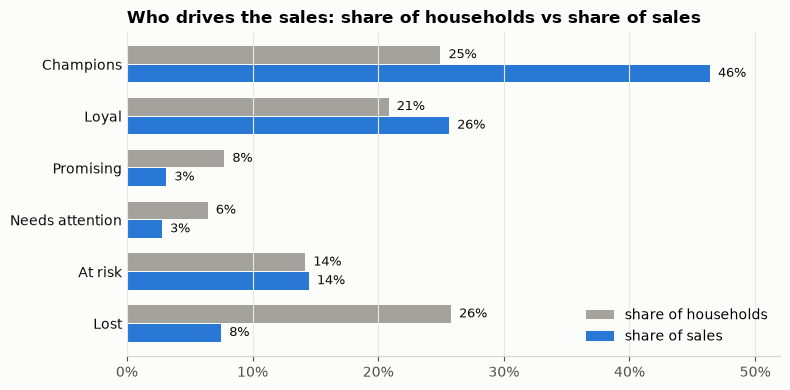

Champions are 25% of households but 46% of sales.


In [ ]:
# share of households vs share of sales, per segment
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(SEGMENT_ORDER))[::-1]
ax.barh(y + 0.18, seg["pct_households"], height=0.34, color=GREY, label="share of households")
ax.barh(y - 0.18, seg["pct_sales"], height=0.34, color=BLUE, label="share of sales")
for yy, h, s in zip(y, seg["pct_households"], seg["pct_sales"]):
    ax.text(h, yy + 0.18, f"  {h:.0%}", va="center", fontsize=9, color=INK)
    ax.text(s, yy - 0.18, f"  {s:.0%}", va="center", fontsize=9, color=INK)
ax.set_yticks(y, SEGMENT_ORDER)
ax.tick_params(axis="y", length=0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Who drives the sales: share of households vs share of sales")
ax.legend(frameon=False, loc="lower right")
ax.margins(x=0.12)
fig.tight_layout(); fig.savefig("../docs/charts/rfm_segments.png", dpi=150); plt.show()

top = seg.loc["Champions"]
print(f"Champions are {top['pct_households']:.0%} of households but {top['pct_sales']:.0%} of sales.")

## 2. Churn risk

- **Gone quiet:** no trip for more than twice the household's own usual longest gap (and at least 4 weeks).
- **Fading:** spent less than half as much in the last 13 weeks as in the 13 weeks before.

"Sales at risk" = what these households spent in the 13 weeks before they started fading or went quiet: the revenue the CRM team would be trying to win back.

In [ ]:
flags = pd.DataFrame({
    "households": [rfm["gone_quiet"].sum(), rfm["fading"].sum(), (rfm["gone_quiet"] | rfm["fading"]).sum()],
    "sales_at_risk_per_13w": [rfm.loc[rfm["gone_quiet"], "prev_13w_sales"].sum(),
                              rfm.loc[rfm["fading"], "prev_13w_sales"].sum(),
                              rfm.loc[rfm["gone_quiet"] | rfm["fading"], "prev_13w_sales"].sum()],
}, index=["gone quiet", "fading", "either"])
flags["pct_households"] = flags["households"] / len(rfm)
flags.round(2)

,households,sales_at_risk_per_13w,pct_households
gone quiet,197,31504.24,0.08
fading,393,112623.55,0.16
either,482,117278.95,0.19


### Does the "gone quiet" flag actually predict churn?

I can't wait to see who comes back, so I go back in time instead. I pretend today is **day 620**, flag households using only data up to then, and check who shopped again in the last 13 weeks (days 621-711). If the flag works, flagged households should come back far less often.

In [ ]:
CUTOFF = 620
hist = baskets[baskets["day"] <= CUTOFF]
future_shoppers = set(baskets.loc[baskets["day"] > CUTOFF, "household_key"])

days = hist[["household_key", "day"]].drop_duplicates().sort_values(["household_key", "day"])
days["gap"] = days.groupby("household_key")["day"].diff()
p90 = days.groupby("household_key")["gap"].quantile(0.9)
last = hist.groupby("household_key")["day"].max()

bt = pd.DataFrame({"days_since_last": CUTOFF - last, "p90_gap": p90}).fillna({"p90_gap": 14})
bt["flagged"] = bt["days_since_last"] > np.maximum(2 * bt["p90_gap"], 28)
bt["came_back"] = bt.index.isin(future_shoppers)

backtest = bt.groupby("flagged")["came_back"].agg(households="count", came_back="mean")
backtest["did_not_come_back"] = 1 - backtest["came_back"]
backtest.index = backtest.index.map({True: "flagged at day 620", False: "not flagged"})
backtest.round(3)

,households,came_back,did_not_come_back
flagged,,,
not flagged,2297,0.952,0.048
flagged at day 620,201,0.677,0.323


In [ ]:
flagged_rate = backtest.loc["flagged at day 620", "did_not_come_back"]
unflagged_rate = backtest.loc["not flagged", "did_not_come_back"]
print(f"{flagged_rate:.0%} of flagged households never came back in the next 13 weeks, "
      f"vs {unflagged_rate:.0%} of the rest ({flagged_rate / max(unflagged_rate, 1e-9):.1f}x).")

32% of flagged households never came back in the next 13 weeks, vs 5% of the rest (6.7x).


### Retention, quarter to quarter

Retention rate = households who shopped in a 13-week quarter **and** the next one ÷ households who shopped in that quarter.

In [ ]:
baskets["quarter"] = (baskets["day"] - 1) // 91 + 1          # 13-week quarters; quarter 8 is partial
active = baskets.groupby("quarter")["household_key"].apply(set)
ret = pd.DataFrame({
    "active_households": active.apply(len),
    "still_active_next_quarter": [len(active[q] & active[q + 1]) if q + 1 in active.index else np.nan for q in active.index],
})
ret["retention_rate"] = ret["still_active_next_quarter"] / ret["active_households"]
ret.round(3)

,active_households,still_active_next_quarter,retention_rate
quarter,,,
1,1781,1654.0,0.929
2,2362,2220.0,0.940
3,2284,2168.0,0.949
4,2271,2170.0,0.956
5,2294,2191.0,0.955
6,2302,2212.0,0.961
7,2316,2178.0,0.940
8,2283,NaN,NaN


## 3. Who responds to coupons?

Only households that received at least one campaign can redeem a coupon, so the **redemption rate** = households that redeemed at least one coupon ÷ households that received a campaign.

Each rate comes with a 95% range (Wilson interval), and a **chi-square test** checks whether the differences between groups are bigger than chance. p < 0.05 means the groups really do differ.

In [ ]:
h = households.merge(rfm[["household_key", "segment"]], on="household_key")
targeted = h[h["campaigns_received"] > 0].copy()
targeted["redeemed"] = targeted["coupons_redeemed"] > 0

def redemption_by(df, col, order=None):
    g = df.groupby(col)["redeemed"].agg(households="count", redeemed="sum")
    if order is not None:
        g = g.reindex([o for o in order if o in g.index])
    g["rate"] = g["redeemed"] / g["households"]
    lo, hi = proportion_confint(g["redeemed"], g["households"], method="wilson")
    g["ci_low"], g["ci_high"] = lo, hi
    p = chi2_contingency(pd.concat([g["redeemed"], g["households"] - g["redeemed"]], axis=1))[1]
    return g, p

by_segment, p_seg = redemption_by(targeted, "segment", SEGMENT_ORDER)
print(f"Overall: {targeted['redeemed'].mean():.0%} of {len(targeted):,} targeted households redeemed at least one coupon")
print(f"By RFM segment (chi-square p = {p_seg:.3f}):")
by_segment.round(3)

Overall: 27% of 1,584 targeted households redeemed at least one coupon
By RFM segment (chi-square p = 0.000):


,households,redeemed,rate,ci_low,ci_high
segment,,,,,
Champions,604,218,0.361,0.324,0.400
Loyal,451,130,0.288,0.248,0.332
Promising,48,7,0.146,0.072,0.272
Needs attention,49,6,0.122,0.057,0.242
At risk,306,61,0.199,0.158,0.248
Lost,126,12,0.095,0.055,0.159


In [ ]:
INCOME_BANDS = {"Under 15K": "Under $35K", "15-24K": "Under $35K", "25-34K": "Under $35K",
                "35-49K": "$35-74K", "50-74K": "$35-74K",
                "75-99K": "$75-124K", "100-124K": "$75-124K",
                "125-149K": "$125K+", "150-174K": "$125K+", "175-199K": "$125K+", "200-249K": "$125K+", "250K+": "$125K+"}
demo = targeted[targeted["has_demographics"]].copy()
demo["income_band"] = demo["income_desc"].map(INCOME_BANDS)
print(f"{len(demo):,} targeted households have demographics")

results, pvals = {}, {}
for col, order in [("age_desc", ["19-24", "25-34", "35-44", "45-54", "55-64", "65+"]),
                   ("income_band", ["Under $35K", "$35-74K", "$75-124K", "$125K+"]),
                   ("hh_comp_desc", None), ("kid_category_desc", None), ("homeowner_desc", None)]:
    results[col], pvals[col] = redemption_by(demo, col, order)

pd.Series(pvals, name="chi-square p-value").round(3)

760 targeted households have demographics


age_desc             0.052
income_band          0.048
hh_comp_desc         0.241
kid_category_desc    0.109
homeowner_desc       0.000
Name: chi-square p-value, dtype: float64

In [ ]:
for col in ["age_desc", "income_band", "hh_comp_desc", "kid_category_desc", "homeowner_desc"]:
    print(f"\n{col}  (p = {pvals[col]:.3f})")
    display(results[col].round(3))


age_desc  (p = 0.052)


,households,redeemed,rate,ci_low,ci_high
age_desc,,,,,
19-24,45,9,0.200,0.109,0.338
25-34,130,52,0.400,0.320,0.486
35-44,187,78,0.417,0.349,0.489
45-54,271,123,0.454,0.396,0.513
55-64,59,24,0.407,0.291,0.534
65+,68,25,0.368,0.263,0.486



income_band  (p = 0.048)


,households,redeemed,rate,ci_low,ci_high
income_band,,,,,
Under $35K,197,68,0.345,0.282,0.414
$35-74K,352,148,0.420,0.370,0.473
$75-124K,120,48,0.400,0.317,0.489
$125K+,91,47,0.516,0.415,0.616



hh_comp_desc  (p = 0.241)


,households,redeemed,rate,ci_low,ci_high
hh_comp_desc,,,,,
1 Adult Kids,43,18,0.419,0.284,0.567
2 Adults Kids,171,79,0.462,0.389,0.537
2 Adults No Kids,246,102,0.415,0.355,0.477
Single Female,140,57,0.407,0.329,0.490
Single Male,88,26,0.295,0.210,0.398
Unknown,72,29,0.403,0.297,0.518



kid_category_desc  (p = 0.109)


,households,redeemed,rate,ci_low,ci_high
kid_category_desc,,,,,
1,107,42,0.393,0.305,0.487
2,55,28,0.509,0.381,0.636
3+,60,31,0.517,0.393,0.638
None/Unknown,538,210,0.390,0.350,0.432



homeowner_desc  (p = 0.000)


,households,redeemed,rate,ci_low,ci_high
homeowner_desc,,,,,
Homeowner,474,218,0.460,0.416,0.505
Probable Owner,11,6,0.545,0.280,0.787
Probable Renter,11,3,0.273,0.097,0.566
Renter,41,20,0.488,0.343,0.635
Unknown,223,64,0.287,0.232,0.350


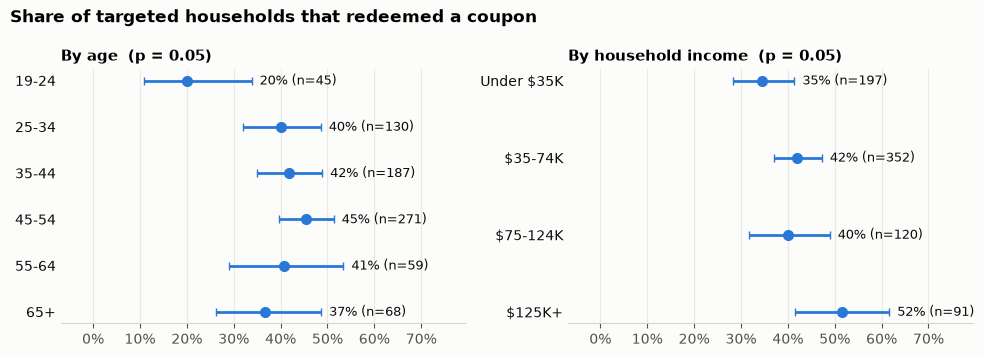

In [ ]:
# redemption rate by age and income, with 95% ranges
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
for ax, col, title in [(axes[0], "age_desc", "By age"), (axes[1], "income_band", "By household income")]:
    r = results[col]
    y = np.arange(len(r))[::-1]
    ax.errorbar(r["rate"], y, xerr=[r["rate"] - r["ci_low"], r["ci_high"] - r["rate"]],
                fmt="o", color=BLUE, ecolor=BLUE, elinewidth=2, capsize=3, markersize=7)
    for yy, v, hi, n in zip(y, r["rate"], r["ci_high"], r["households"]):
        ax.text(hi, yy, f"  {v:.0%} (n={n})", va="center", fontsize=9, color=INK)
    ax.set_yticks(y, r.index)
    ax.tick_params(axis="y", length=0)
    ax.set_title(f"{title}  (p = {pvals[col]:.2f})", fontsize=11)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.margins(x=0.35)
fig.suptitle("Share of targeted households that redeemed a coupon", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig("../docs/charts/coupon_redemption_by_demographic.png", dpi=150); plt.show()

## What I found

1. **A quarter of households drive almost half the sales.** Champions are 25% of households and 46% of sales. With Loyal customers, it's 46% of households and 72% of sales.
2. **"At risk" is the group to win back.** 355 households (14%) used to shop about as often as Loyal customers (106 trips) but haven't been in for 33 days on average. They're worth $1.07M in lifetime sales.
3. **One in five households shows a churn warning sign.** 482 households (19%) have gone quiet or are fading. Before slipping, they spent $117K a quarter, about 12% of a quarter's sales.
4. **My churn flag works as an early warning.** Households flagged at day 620 were 6.7x more likely never to come back (32% vs 4.8%). Two-thirds of flagged households did return, though, so the flag marks the moment to step in, not a lost customer.
5. **Retention is steady.** About 95% of households active in one quarter shop again the next (94-96% from quarter 2 on).
6. **Coupons mostly go to customers who'd shop anyway.** 36% of targeted Champions redeemed a coupon, against 20% of At risk and 9.5% of Lost households (p < 0.001).
7. **Higher-income households redeem more; the youngest redeem least.** 52% of $125K+ households redeemed vs 35% under $35K (p = 0.048), and 20% of 19-24 year-olds vs about 40-45% for other ages (p = 0.052). With five demographic tests, I treat these as leaning, not proven.
8. **Owners and renters redeem alike; unknown profiles don't.** Homeowners 46%, renters 49%, but only 29% of households with unknown homeowner status (p < 0.001). Those are likely households less engaged with the loyalty programme.
9. **Put together with Part 2:** campaigns showed no measurable spending lift, and their coupons mostly reward the best, richest customers. The obvious test is to redirect coupons towards At risk households.